<a href="https://colab.research.google.com/github/Ahmedark77/Introduction-to-AI/blob/feature-branch/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
# =========================================================
# 📌 2. LOAD DATASET
# =========================================================

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# =========================================================
# 📌 3. DATA PREPROCESSING
# =========================================================

# Check missing values
print(df.isnull().sum())

# Feature Scaling (VERY IMPORTANT for clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


k=2 | silhouette=0.2593
k=3 | silhouette=0.2849
k=4 | silhouette=0.2602
k=5 | silhouette=0.2016
k=6 | silhouette=0.2372
k=7 | silhouette=0.2036

Best k = 3


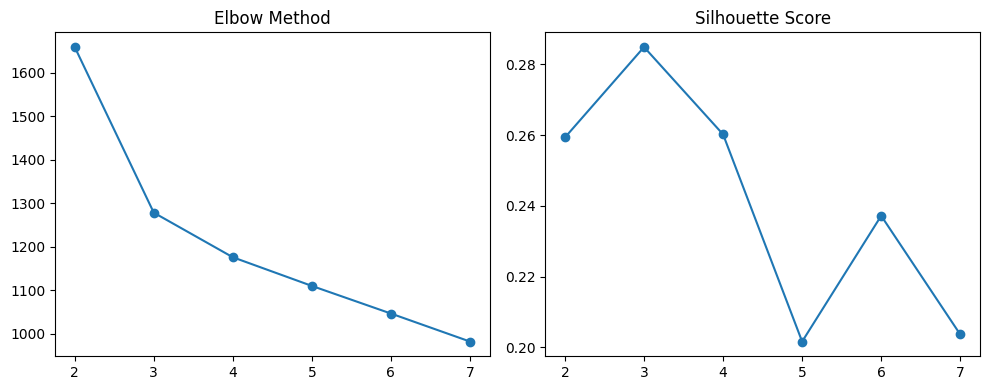

In [12]:
# ============================================
# STEP 4: Find optimal number of clusters
# ============================================
# ============================================
# 4. FIND BEST K (ELBOW + SILHOUETTE)
# ============================================

K_range = range(2, 8)
inertia = []
silhouette_scores = []

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_data)

    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, model.labels_))

    print(f"k={k} | silhouette={silhouette_scores[-1]:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print("\nBest k =", best_k)


# Plot results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# 5. CLUSTERING
# ============================================

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

hierarchical = AgglomerativeClustering(n_clusters=best_k)
hierarchical_labels = hierarchical.fit_predict(scaled_data)

print("KMeans Silhouette:", silhouette_score(scaled_data, kmeans_labels))
print("Hierarchical Silhouette:", silhouette_score(scaled_data, hierarchical_labels))

KMeans Silhouette: 0.2848589191898987
Hierarchical Silhouette: 0.2774439826952266


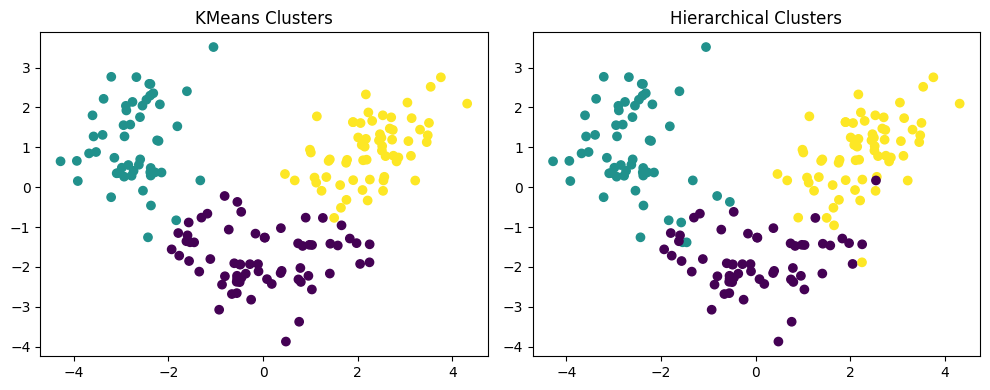

In [15]:
# ============================================
# 6. PCA VISUALIZATION
# ============================================

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")

plt.subplot(1,2,2)
plt.scatter(pca_data[:,0], pca_data[:,1], c=hierarchical_labels)
plt.title("Hierarchical Clusters")

plt.tight_layout()
plt.show()


In [16]:
# ============================================
# STEP 6: MODEL EVALUATION
# ============================================

print("\n--- STEP 6: Model Evaluation ---")

from sklearn.metrics import silhouette_score

# Evaluate KMeans
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

# Evaluate Hierarchical Clustering
hierarchical_score = silhouette_score(scaled_data, hierarchical_labels)
print(f"Hierarchical Silhouette Score: {hierarchical_score:.4f}")

# Compare models
if kmeans_score > hierarchical_score:
    best_model = "K-Means"
    best_score = kmeans_score
else:
    best_model = "Hierarchical"
    best_score = hierarchical_score


--- STEP 6: Model Evaluation ---
K-Means Silhouette Score: 0.2849
Hierarchical Silhouette Score: 0.2774


In [17]:
# ============================================
# STEP 8: DEPLOYMENT & MONITORING
# ============================================

print("\n--- STEP 8: Deployment & Monitoring ---")

print("\nDEPLOYMENT SCENARIO:")
print("""
The clustering model can be deployed as part of a wine analytics system
that automatically groups new wine samples based on chemical properties.
This can be integrated into a REST API or cloud-based pipeline.
""")

print("\nCHALLENGES:")
print("""
- Latency: clustering is fast but preprocessing must be optimized
- Scalability: large datasets may slow PCA + clustering steps
- Data drift: wine characteristics may change over time
""")

print("\nMONITORING STRATEGY:")
print("""
- Track silhouette score over time
- Monitor feature distribution shifts
- Retrain model periodically (monthly/quarterly)
- Set alerts if performance drops below threshold
""")


--- STEP 8: Deployment & Monitoring ---

DEPLOYMENT SCENARIO:

The clustering model can be deployed as part of a wine analytics system
that automatically groups new wine samples based on chemical properties.
This can be integrated into a REST API or cloud-based pipeline.


CHALLENGES:

- Latency: clustering is fast but preprocessing must be optimized
- Scalability: large datasets may slow PCA + clustering steps
- Data drift: wine characteristics may change over time


MONITORING STRATEGY:

- Track silhouette score over time
- Monitor feature distribution shifts
- Retrain model periodically (monthly/quarterly)
- Set alerts if performance drops below threshold

